
# Steam Market Analytics
 
 
 This notebook sits on top of our Gold data layer to figure out what actually drives game visibility, popularity, and sales on Steam. Instead of looking at metrics in a vacuum, we're combining genre trends, OS compatibility, pricing, and localization to see what moves the needle.
 
 **Data Architecture**
 The pipeline splits into two layers derived from our core `fact_games` model:
 * **Gold Core:** Keeps things consistent across the platform using normalized canonical models.
 * **Gold Serving:** Uses denormalized marts optimized for quick filtering, aggregations, and BI dashboard consumption.
 
 
 Beyond just describing the Steam ecosystem, the goal here is to isolate the structural patterns shared by the platform's most commercially successful games.


In [0]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

sns.set_theme(style="whitegrid")

# Market Overview

## Most Popular Games

name,ccu,owners_midpoint
Counter-Strike: Global Offensive,874053,75000000
Dota 2,852995,350000000
PUBG: BATTLEGROUNDS,339287,75000000
Apex Legends,314468,35000000
Lost Ark,273088,35000000
Call of Duty: Modern Warfare II,206441,3500000
Grand Theft Auto V,140671,35000000
New World,127379,75000000
Rust,121146,35000000
NARAKA: BLADEPOINT,116729,7500000


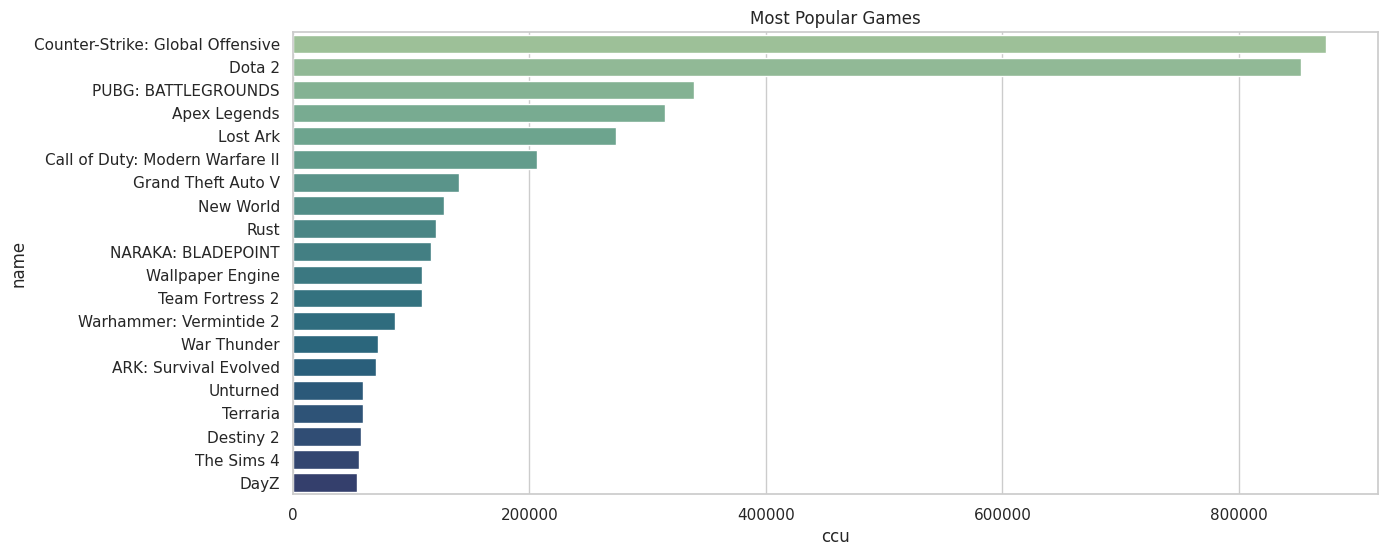

In [0]:
query = """

SELECT

name,

ccu,

owners_midpoint

FROM steam.gold.fact_games

WHERE ccu IS NOT NULL

ORDER BY ccu DESC

LIMIT 20

"""



df = spark.sql(query)

display(df)



pdf = df.toPandas()



plt.figure(figsize=(14,6))

bar_colors = sns.color_palette("crest", len(pdf))

sns.barplot(data=pdf, x='ccu', y='name', palette=bar_colors)

plt.title('Most Popular Games')

plt.show() 



### Interpretation

* **Power-Law Engagement Distribution:** Steam’s player engagement follows a clear power-law distribution, where a marginal cohort of top-tier titles captures the vast majority of active platform volume.
* **Valve Ecosystem Dominance:** *CS:GO* and *Dota 2* command the highest positions, with both titles approaching **900k concurrent players (CCU)** and vastly outperforming the rest of the market.
* **Live-Service Engagement Drivers:** The upper ranks are populated almost entirely by multiplayer franchises like *PUBG*, *Apex Legends*, and *Call of Duty*, confirming that persistent online ecosystems are the primary drivers of high daily player retention.
* **Exceptional Portfolio Longevity:** Legacy titles such as *GTA V*, *Rust*, *Terraria*, and *Team Fortress 2* continue to maintain robust player bases. This underscores their long-term popularity and structural resilience against newer market entries.

**Strategic Takeaway:** Steam's most active games are dominated by large established multiplayer titles capable of maintaining player activity over long periods of time.

## Best Selling Games

name,estimated_revenue,ccu,price
ELDEN RING,2.09965E9,23687,59.99
New World,1.49925E9,127379,19.99
Rust,1.39965E9,121146,39.99
Grand Theft Auto V,1.0493E9,140671,29.98
Cyberpunk 2077,8.9985E8,50989,59.99
HITMAN 2,7.49925E8,1150,99.99
Tom Clancy's Rainbow Six Siege,6.9965E8,31239,19.99
Valheim,6.9965E8,21890,19.99
The Witcher 3: Wild Hunt,5.9985E8,22812,39.99
Mount & Blade II: Bannerlord,5.9985E8,51864,39.99


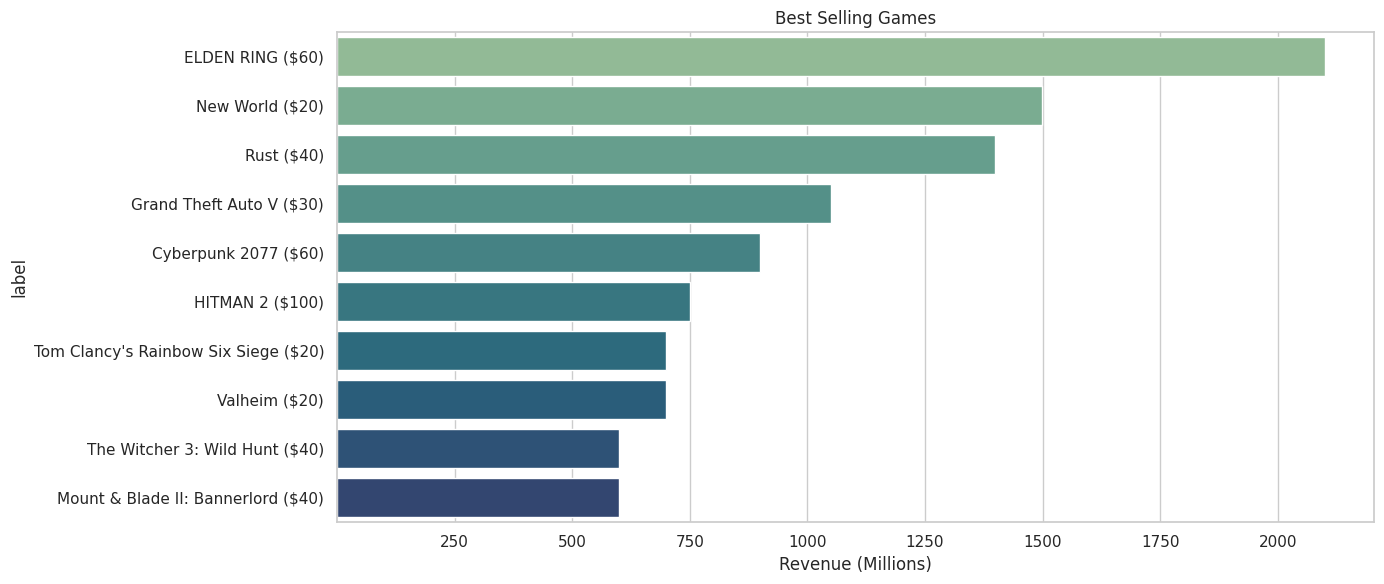

In [0]:

query = """
SELECT
    name,
    estimated_revenue,
    ccu,
    price
FROM steam.gold.fact_games
WHERE estimated_revenue IS NOT NULL
ORDER BY estimated_revenue DESC
LIMIT 10
"""

df = spark.sql(query)
display(df)

pdf = df.toPandas()

plt.figure(figsize=(14,6))

pdf['estimated_revenue'] = pdf['estimated_revenue'] / 1000000

pdf['label'] = pdf.apply(
    lambda row: f"{row['name']} (${row['price']:.0f})",
    axis=1
)

sns.barplot(data=pdf, x='estimated_revenue', y='label', palette='crest')

plt.xlabel('Revenue (Millions)')
plt.title('Best Selling Games')
plt.xlim(left=0.50)
plt.tight_layout()
plt.show()



### Interpretation

* **Revenue Distribution:** Revenue is concentrated among a small number of top-selling titles, though the distribution shows a steady step-down rather than a single dominant outlier completely flattening the rest of the cohort.
* **The Blockbuster Impact:** *ELDEN RING* leads the market significantly with over **2.1 billion in estimated revenue**, demonstrating the massive financial footprint a premium, full-priced game ($60) can achieve.
* **Long-Tail Commercial Lifespan:** Older games like *Grand Theft Auto V*, *Rust*, and *The Witcher 3: Wild Hunt* remain highly competitive among Steam's top revenue earners, highlighting the remarkable long-term selling power of successful franchises.
* **Pricing Model Variations:** The chart shows that different pricing strategies can achieve comparable revenue results. For instance, the highly premium *HITMAN 2* ($100) generates similar total revenue to lower-priced, high-volume hits like *Tom Clancy's Rainbow Six Siege* ($20) and *Valheim* ($20).

**Strategic Takeaway:** Marketplace profitability is driven by two distinct commercial approaches. Some titles rely on high volume at accessible price points ($20–$30), while others leverage major brand reputation and high upfront pricing ($60–$100) to maximize financial returns.

## Top Publishers by Number of Games

publisher_name,total_games
Big Fish Games,423
8floor,202
SEGA,162
Strategy First,151
Square Enix,140
Choice of Games,140
Unknown,134
Sekai Project,132
HH-Games,132
Ubisoft,126


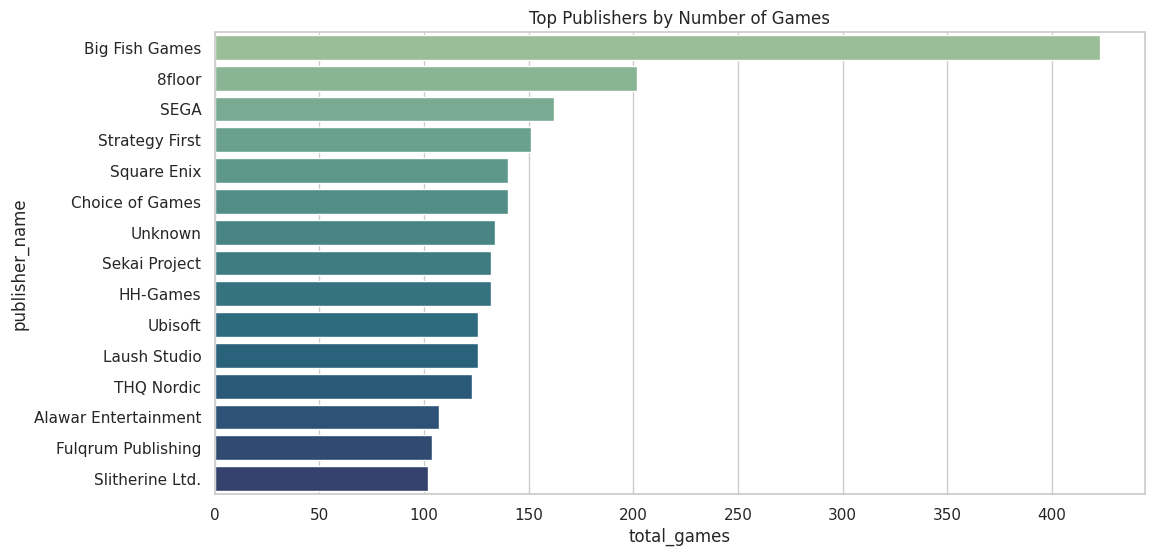

In [0]:

query = """
SELECT
    dp.publisher_name,
    COUNT(DISTINCT mpp.appid) AS total_games
FROM steam.gold.mart_publisher_performance mpp
JOIN steam.gold.dim_publishers dp
    ON mpp.publisher_key = dp.publisher_key
GROUP BY dp.publisher_name
ORDER BY total_games DESC
LIMIT 15
"""

publisher_df = spark.sql(query)
display(publisher_df)

pdf = publisher_df.toPandas()

plt.figure(figsize=(12,6))
bar_colors = sns.color_palette("crest", len(pdf))

sns.barplot(data=pdf, x='total_games', y='publisher_name', palette=bar_colors)
plt.title('Top Publishers by Number of Games')
plt.show()


### Interpretation

* The number of published games is highly uneven across publishers. While most top publishers release around **100–150 titles**, a few companies adopt much larger-scale publishing strategies.
* **Big Fish Games** stands out clearly with more than **400 published games**, almost double the volume of the second-ranked publisher, indicating a strong focus on quantity and catalog size.
* Major industry publishers such as **SEGA**, **Square Enix**, and **Ubisoft** appear in the ranking but do not dominate it, showing that market visibility on Steam is not limited to traditional AAA companies.
* Several lesser-known publishers also rank highly, suggesting that Steam allows specialized or high-volume publishers to secure a significant presence on the platform.
* After the top few publishers, the differences between ranks become much smaller, highlighting a highly competitive and fragmented publishing ecosystem.

**Overall Takeway:** The chart suggests that Steam’s publishing landscape is shaped not only by major gaming brands, but also by publishers relying on large and diversified catalogs to maximize their platform presence.


## Best Rated Games

name,positive_ratio,total_reviews,owners_midpoint
Stardew Valley,0.9817,506841,15000000
Wallpaper Engine,0.9807,572127,35000000
Terraria,0.9784,1037091,35000000
Left 4 Dead 2,0.9745,660664,35000000
Euro Truck Simulator 2,0.9734,587983,15000000
Garry's Mod,0.9663,891238,35000000
The Witcher 3: Wild Hunt,0.9616,657872,15000000
Team Fortress 2,0.9365,903830,75000000
Among Us,0.9179,638716,35000000
ELDEN RING,0.904,542271,35000000


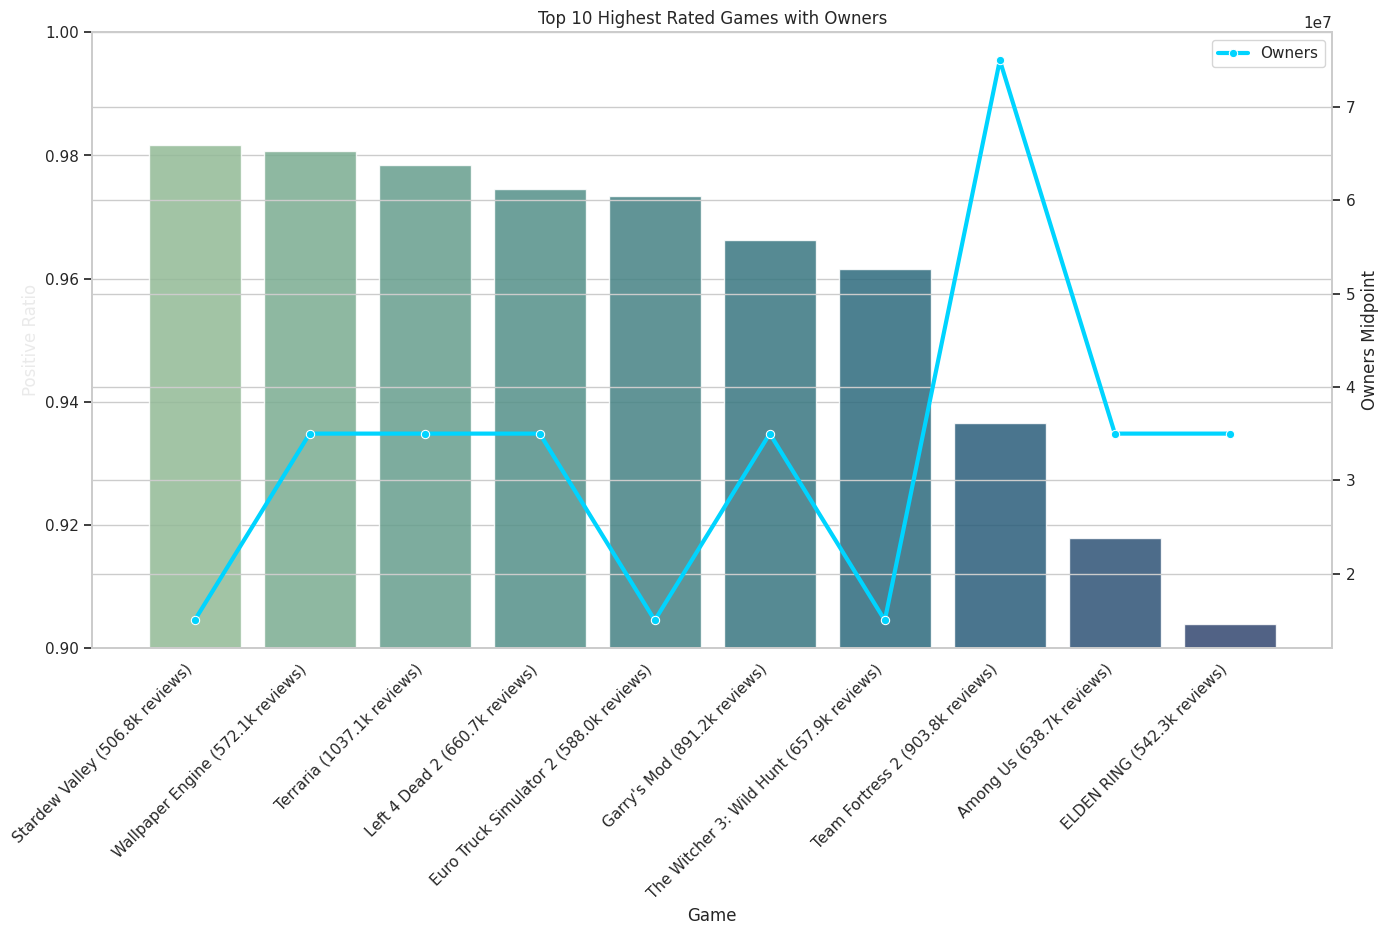

In [0]:
query = """
SELECT
    name,
    ROUND(positive_ratio, 4) AS positive_ratio,
    (positive + negative) AS total_reviews,
    owners_midpoint

FROM steam.gold.fact_games

WHERE positive_ratio IS NOT NULL
AND owners_midpoint IS NOT NULL

AND (positive + negative) > 500000

ORDER BY
    positive_ratio DESC,
    owners_midpoint DESC

LIMIT 10
"""

df = spark.sql(query)
display(df)

pdf = df.toPandas()
pdf['label'] = pdf.apply(
    lambda row: f"{row['name']} ({row['total_reviews'] / 1_000:.1f}k reviews)",
    axis=1
)

fig, ax1 = plt.subplots(figsize=(16,8))

# Barplot for positive ratio
bar_colors = sns.color_palette("crest", len(pdf))

sns.barplot(
    data=pdf,
    x='label',
    y='positive_ratio',
    palette=bar_colors,
    ax=ax1,
    alpha=0.85
)
ax1.set_ylim(0.90, 1.0)

ax1.set_ylabel('Positive Ratio', color='#EAEAEA', fontsize=12)
ax1.set_xlabel('Game', fontsize=12)

ax1.set_title('Top 10 Highest Rated Games with Owners')

plt.xticks(rotation=45, ha='right')

# Owners line
ax2 = ax1.twinx()

sns.lineplot(
    data=pdf,
    x='label',
    y='owners_midpoint',
    marker='o',
    linewidth=3,
    color='#00D4FF',
    ax=ax2,
    label='Owners'
)

ax2.set_ylabel('Owners Midpoint')

plt.show()


### Interpretation

* **High Universal Satisfaction Baseline:** All games in the ranking maintain exceptionally high positive review ratios, generally above **90%**, indicating consistently strong player satisfaction across completely different genres and player communities.
* **Narrow Quality Margins:** The difference in approval percentages across these top-tier titles is remarkably small. Even the lower boundary of the cohort, **ELDEN RING**, exceeds **90.4% positive reviews**, while **Stardew Valley** approaches **98.2%**.
* **The Volume and Audience Stress Test:** Integrating ownership data adds crucial context to the chart. Maintaining a very high approval ratio becomes exponentially harder as the absolute size of the player base expands and shifts from a core niche to a more critical, mainstream audience.
* **Exceptional Scale and Resilience:** Titles like **Terraria**, **Left 4 Dead 2**, and notably **Team Fortress 2** stand out by pairing immense ownership levels with extremely high review scores. This unique combination highlights exceptional long-term popularity and community satisfaction sustained over many years.
* **Niche vs. Mass-Market Success:** The data reveals two distinct profiles: specialized games that achieve near-perfection by deeply satisfying a focused audience, versus cultural phenomena that preserve an elite rating while absorbing tens of millions of players.

**Strategic Takeaway:** The data show that a popular game isn't just getting a 98% rating with a small group of fans. The real winners are games like Team Fortress 2 or Terraria, which manage to keep millions of players satisfied over many years without their scores plummeting as they grow.

## Steam Releases Over Time

year,total_games_released
1997,1
1997,1
1998,1
1999,1
1999,1
1999,1
2000,2
2001,2
2001,1
2001,1


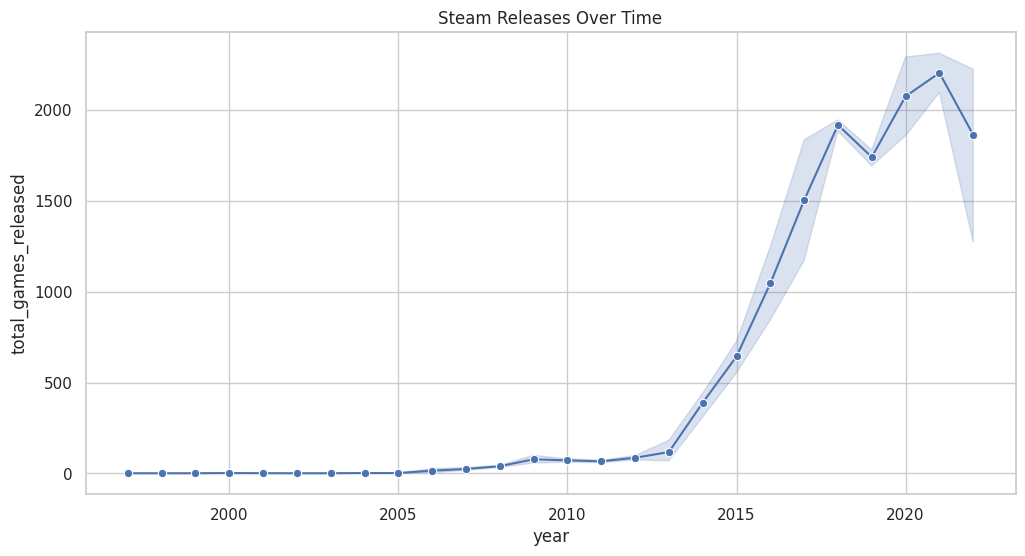

In [0]:

query = """
SELECT
    year,
    total_games_released
FROM steam.gold.market_trends
ORDER BY year
"""

df = spark.sql(query)
display(df)

pdf = df.toPandas()

plt.figure(figsize=(12,6))
sns.lineplot(data=pdf, x='year', y='total_games_released', marker='o')
plt.title('Steam Releases Over Time')
plt.show()


### Interpretation

* **Pre-2014 Curated Baseline:** Before 2013–2014, annual Steam releases remained relatively low and stable, reflecting a more selective, curated, and gatekept publishing ecosystem.
* **The Post-2014 Scale Shift:** A major structural shift occurred after 2014, when yearly releases began increasing exponentially. Within a few years, Steam transitioned from hosting a few hundred new releases per year to an operating volume of more than 2,000 annual launches.
* **Lowered Entry Barriers:** This rapid expansion indicates a significant reduction in platform publishing barriers, allowing a much wider array of independent studios and solo developers to access the storefront.
* **The 2019 Core Slowdown:** A temporary slowdown in the upward trend appears around 2019, reflecting market adjustments and changes in storefront dynamics before release volumes surged again during the 2020–2021 period.
* **The Pandemic Marketplace Accelerator:** The COVID-19 pandemic acted as an immediate catalyst for the digital ecosystem. Widespread lockdowns drastically increased global gaming consumption, making digital distribution even more central for both active players and developers trying to reach them.
* **Sustained High-Volume Normal:** Although release volumes declined slightly after the historic 2021 peak, the platform's baseline remains at historically high levels. This confirms that Steam has permanently evolved into a highly saturated marketplace rather than experiencing a temporary pandemic bubble.

**Overall Takeaway:** The timeline shows how Steam evolved from a small curated storefront into a immense open marketplace where releasing a game is easier than ever, but standing out has become much more difficult.

## Price distribution

price_range,total_games
0-1€,13760
1-2€,4486
2-3€,3903
3-4€,2678
4-5€,6374
5-6€,1913
6-7€,1920
7-8€,1643
8-9€,781
9-10€,6173


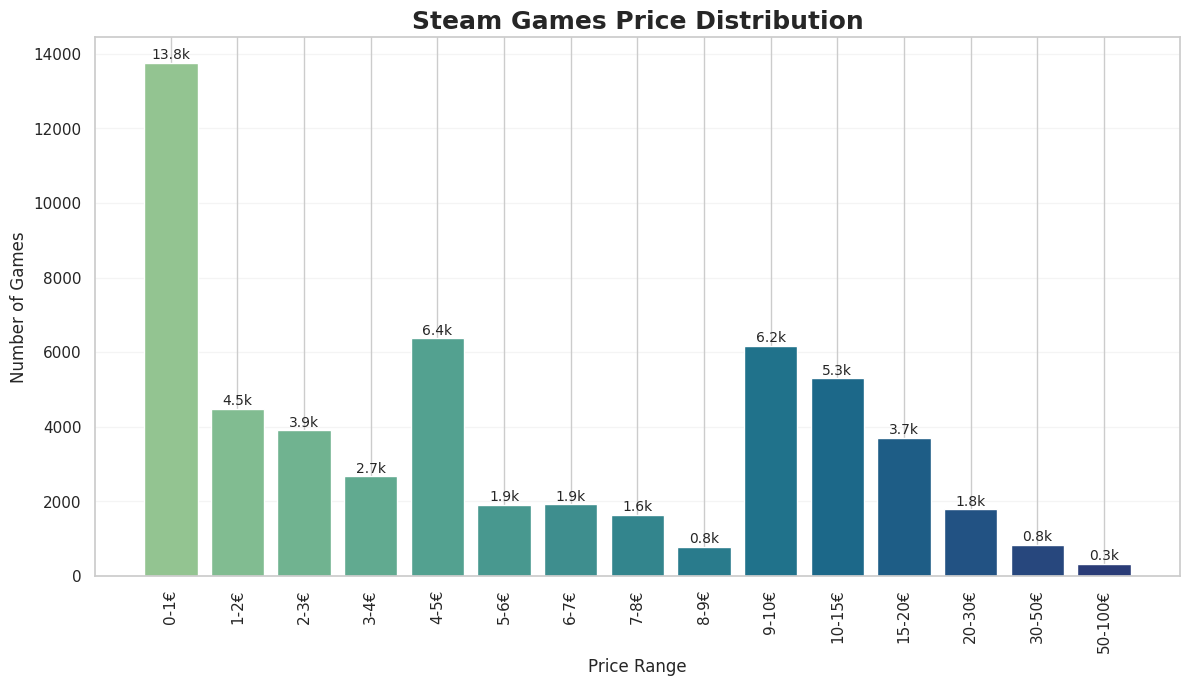

In [0]:
query = """
SELECT
    CASE
        WHEN price BETWEEN 0 AND 1 THEN '0-1€'
        WHEN price BETWEEN 1 AND 2 THEN '1-2€'
        WHEN price BETWEEN 2 AND 3 THEN '2-3€'
        WHEN price BETWEEN 3 AND 4 THEN '3-4€'
        WHEN price BETWEEN 4 AND 5 THEN '4-5€'
        WHEN price BETWEEN 5 AND 6 THEN '5-6€'
        WHEN price BETWEEN 6 AND 7 THEN '6-7€'
        WHEN price BETWEEN 7 AND 8 THEN '7-8€'
        WHEN price BETWEEN 8 AND 9 THEN '8-9€'
        WHEN price BETWEEN 9 AND 10 THEN '9-10€'
        WHEN price BETWEEN 10 AND 15 THEN '10-15€'
        WHEN price BETWEEN 15 AND 20 THEN '15-20€'
        WHEN price BETWEEN 20 AND 30 THEN '20-30€'
        WHEN price BETWEEN 30 AND 50 THEN '30-50€'
        ELSE '50-100€'
    END AS price_range,

    COUNT(*) AS total_games

FROM steam.gold.fact_games

WHERE price IS NOT NULL

GROUP BY price_range

ORDER BY
    CASE price_range
        WHEN '0-1€' THEN 1
        WHEN '1-2€' THEN 2
        WHEN '2-3€' THEN 3
        WHEN '3-4€' THEN 4
        WHEN '4-5€' THEN 5
        WHEN '5-6€' THEN 6
        WHEN '6-7€' THEN 7
        WHEN '7-8€' THEN 8
        WHEN '8-9€' THEN 9
        WHEN '9-10€' THEN 10
        WHEN '10-15€' THEN 11
        WHEN '15-20€' THEN 12
        WHEN '20-30€' THEN 13
        WHEN '30-50€' THEN 14
        ELSE 15
    END
"""

df = spark.sql(query)

display(df)

pdf = df.toPandas()

plt.figure(figsize=(14,7))

colors = sns.color_palette("crest", len(pdf))

bars = plt.bar(
    pdf['price_range'],
    pdf['total_games'],
    color=colors
)

plt.title('Steam Games Price Distribution', fontsize=18, weight='bold')
plt.xlabel('Price Range')
plt.ylabel('Number of Games')

plt.xticks(rotation=90)

# labels on bars
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 100,
        f'{height/1000:.1f}k',
        ha='center',
        fontsize=10
    )

plt.grid(axis='y', alpha=0.2)

plt.show()

### Interpretation

* **Low-Cost Marketplace Concentration:** Most Steam games are concentrated in the lower pricing tiers, with a vast majority of the catalog sitting between **0€ and 10€**. This indicates a platform heavily populated by budget-conscious software.
* **The Under-1€ Volume Spike:** The **0–1€ range** is the largest single segment by a wide margin (**13.8k titles**). This massive volume reflects the heavy presence of free-to-play games, micro-budget entries, and deeply discounted software.
* **Psychological Pricing Anchors:** Clear volume spikes appear specifically in the **4–5€ (6.4k)** and **9–10€ (6.2k)** brackets. This confirms that developers frequently cluster around traditional pricing milestones like **4.99€** and **9.99€**.
* **The Premium Drop-Off:** The volume of releases decreases progressively as price points increase. Titles priced above **20€** become relatively scarce, and the premium **50–100€ range** represents the smallest cohort on the chart with only **300 games**.

**Strategic Takeaway:** The data highlights a highly crowded, bottom-heavy market where the under-10€ space faces intense volume competition. Conversely, setting a price point above 20€ immediately removes a game from this hyper-congested tier and places it within a much smaller, higher-value competitive pool.


## Supported languages

language,total_games
English,55020
German,13983
French,13393
Russian,12900
Simplified Chinese,12770
Spanish,12809
Japanese,10357


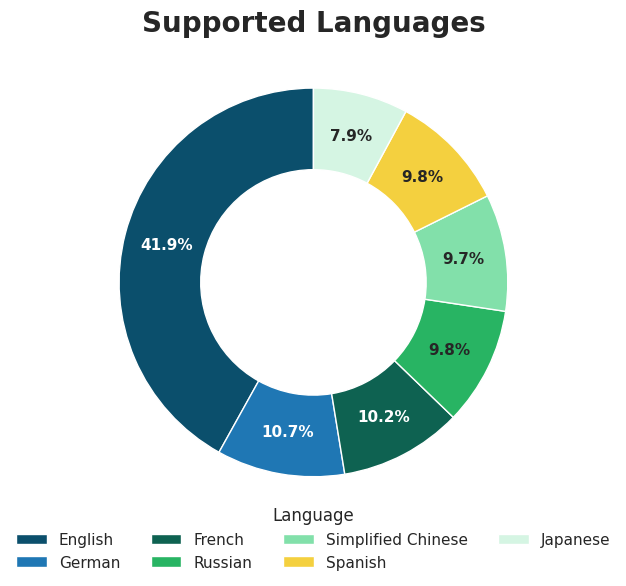

In [0]:
query = """

SELECT 'English' AS language, COUNT(*) AS total_games
FROM steam.gold.fact_games
WHERE english = true

UNION ALL

SELECT 'German', COUNT(*)
FROM steam.gold.fact_games
WHERE german = true

UNION ALL

SELECT 'French', COUNT(*)
FROM steam.gold.fact_games
WHERE french = true

UNION ALL

SELECT 'Russian', COUNT(*)
FROM steam.gold.fact_games
WHERE russian = true

UNION ALL

SELECT 'Simplified Chinese', COUNT(*)
FROM steam.gold.fact_games
WHERE simplified_chinese = true

UNION ALL

SELECT 'Spanish', COUNT(*)
FROM steam.gold.fact_games
WHERE spanish = true

UNION ALL

SELECT 'Japanese', COUNT(*)
FROM steam.gold.fact_games
WHERE japanese = true

"""

df = spark.sql(query)

display(df)

pdf = df.toPandas()

colors = [
    '#0B4F6C',  # English
    '#1F77B4',  # German
    '#0E6251',  # French
    '#28B463',  # Russian
    '#82E0AA',  # Simplified Chinese
    '#F4D03F',  # Spanish
    '#D5F5E3'   # Japanese
]

plt.figure(figsize=(9,6))

wedges, texts, autotexts = plt.pie(
    pdf['total_games'],
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={
        'width':0.42,
        'edgecolor':'white'
    },
    pctdistance=0.78,
    textprops={
        'fontsize':11,
        'weight':'bold'
    }
)

autotexts[0].set_color('white') 
autotexts[1].set_color('white') 
autotexts[2].set_color('white') 

plt.legend(
    pdf['language'],
    title='Language',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.12),
    ncol=4,
    frameon=False
)

plt.title(
    'Supported Languages',
    fontsize=20,
    weight='bold'
)

plt.tight_layout()

plt.show()

### Interpretation

* **Dominance of English:** English largely dominates the platform, representing nearly **42% of supported languages**, making it the clear baseline standard for global distribution on Steam.
* **Balanced Secondary Tier:** Beyond English, the market share becomes remarkably evenly distributed. Core languages such as **German (10.7%)**, **French (10.2%)**, **Russian (9.8%)**, and **Spanish (9.8%)** each represent roughly a tenth of the chart.
* **East Asian Market Footprint:** The strong presence of **Simplified Chinese (9.7%)** and **Japanese (7.9%)** underscores the critical role of Asian markets within Steam’s international ecosystem.
* **Multi-Regional Audience:** No single secondary language clearly dominates the others. This flat distribution indicates that Steam’s audience is highly internationalized and split evenly across multiple major geographic regions.

**Strategic Takeaway:** The data shows that while English is a mandatory foundation, successful international distribution cannot rely on a single secondary market. To maximize global reach, developers must adopt a multi-region localization strategy that targets European, Russian, and East Asian communities simultaneously.

## Games Restricted for 16/18+

In [0]:
query = """
SELECT
    CASE
        WHEN required_age >= 18 THEN '18+'
        WHEN required_age >= 16 THEN '16+'
        ELSE 'Under 16'
    END AS age_category,

    COUNT(*) AS total_games

FROM steam.gold.fact_games

GROUP BY
    CASE
        WHEN required_age >= 18 THEN '18+'
        WHEN required_age >= 16 THEN '16+'
        ELSE 'Under 16'
    END
"""

df = spark.sql(query)

display(df)

age_category,total_games
Under 16,55289
18+,222
16+,76


### Interpretation

* **Overwhelming General Audience Baseline:** The Steam catalog is overwhelmingly composed of games classified under the **“Under 16” cohort**, which accounts for nearly the entire dataset with more than **55,000 titles**.
* **Scarcity of Age-Restricted Content:** Games restricted to mature audiences remain extremely rare in comparison. Only **222 titles carry an 18+ classification**, and fewer than **100 titles are rated 16+**.
* **Broad Market Accessibility:** This stark imbalance indicates that the vast majority of software on the platform is developed for wide public accessibility, intentionally avoiding heavily restricted age brackets.
* **Platform Classification Dynamics:** The minimal presence of mature ratings suggests that strict formal age classifications are less prevalent or less uniformly applied across the open PC ecosystem compared to tightly regulated console storefronts.

**Strategic Takeaway:** The data proves that Steam’s marketplace is largely oriented toward general audiences, with age-restricted games representing only a marginal share of the platform’s total catalog.


# Genres analysis

## Most Represented Genres

genre_name,total_games
Indie,39658
Action,23727
Casual,22066
Adventure,21402
Strategy,10878
Simulation,10819
RPG,9526
Early Access,6140
Free to Play,3390
Sports,2661


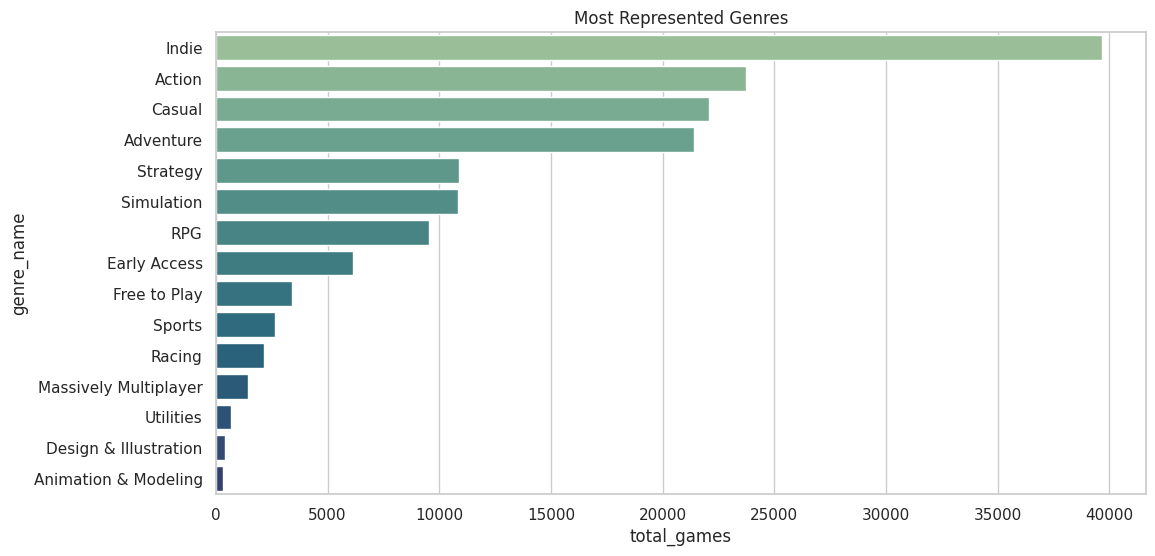

In [0]:

query = """
SELECT
    dg.genre_name,
    COUNT(*) AS total_games
FROM steam.gold.bridge_game_genres bgg
JOIN steam.gold.dim_genres dg
    ON bgg.genre_key = dg.genre_key
GROUP BY dg.genre_name
ORDER BY total_games DESC
LIMIT 15
"""

df = spark.sql(query)
display(df)

pdf = df.toPandas()
bar_colors = sns.color_palette("crest", len(pdf))
plt.figure(figsize=(12,6))
sns.barplot(data=pdf, x='total_games', y='genre_name', palette=bar_colors)


plt.title('Most Represented Genres')
plt.show()


### Interpretation

* **Dominance of Independent Development:** **Indie** is by far the most represented tag on Steam, with nearly **40,000 games**. This massive volume places it significantly ahead of every other category, cementing the platform as the global hub for independent creators.
* **Mainstream Core Genres:** Traditional gaming categories such as **Action**, **Adventure**, and **Casual** occupy a major share of the platform, each containing tens of thousands of titles and forming the foundational core of the storefront's catalog.
* **Robust Mid-Tier Representation:** Mid-sized genres like **Strategy**, **Simulation**, and **RPG** maintain a strong, healthy volume. This highlights the deep diversity of player interests and the presence of dedicated, sustainable communities on Steam.
* **High-Barrier and Specialized Niches:** Categories such as **Massively Multiplayer (MMO)**, **Sports**, and **Racing** are comparatively small. This suggests these genres face higher entry barriers, requiring either specialized audiences or larger development resources to produce.
* **Expansion Beyond Traditional Gaming:** The visibility of categories like **Early Access**, **Utilities**, and **Design & Illustration** shows that Steam has evolved beyond a pure video game storefront into a broader digital distribution platform for creative software and active development models.

**Strategic Takeaway:** The data highlights a marketplace strongly driven by independent development and broad genre diversity. While **Action**, **Adventure**, and **Casual** remain the most represented genres due to their wide player appeal and strong demand, they are also the most saturated areas of the platform. As a result, succeeding in these categories depends heavily on visibility and discoverability, since new games must compete against an extremely large number of similar titles.



## Best Reviewed Genres

genre_name,avg_positive_ratio
Game Development,0.74
Indie,0.74
Casual,0.74
Adventure,0.74
Action,0.73
RPG,0.73
Strategy,0.72
Accounting,0.72
Design & Illustration,0.72
Free to Play,0.72


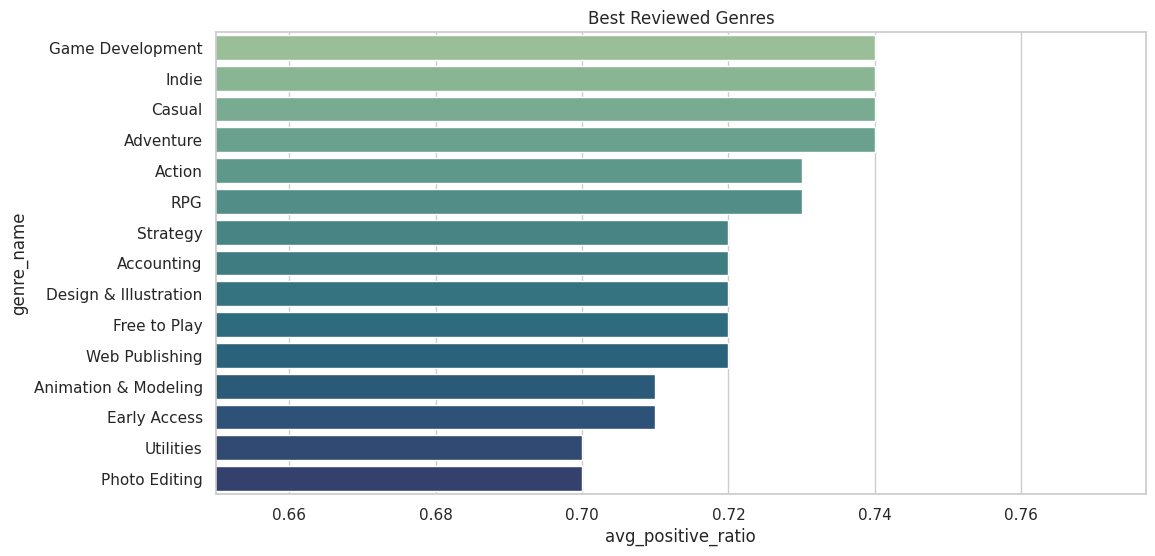

In [0]:

query = """
SELECT
    genre_name,
    AVG(avg_positive_ratio) AS avg_positive_ratio
FROM steam.gold.genre_platform_summary
GROUP BY genre_name
ORDER BY avg_positive_ratio DESC
LIMIT 15
"""

df = spark.sql(query)
display(df)

pdf = df.toPandas()

plt.figure(figsize=(12,6))
bar_colors = sns.color_palette("crest", len(pdf))
sns.barplot(data=pdf, x='avg_positive_ratio', y='genre_name', palette=bar_colors)
plt.xlim(left=0.65)
plt.title('Best Reviewed Genres')
plt.show()


### Interpretation

* **Consistent Global Satisfaction:** Average positive review ratios remain remarkably close across genres, generally ranging between **70% and 74%**. This narrow spread suggests that baseline player satisfaction is fairly consistent throughout the platform.
* **The Independent Quality Edge:** **Indie**, **Casual**, **Adventure**, and **Game Development** categories achieve the highest average approval scores. This indicates a high level of user satisfaction, often driven by focused communities and clear product expectations.
* **Mass-Market Resilience:** Major mainstream genres such as **Action**, **RPG**, and **Strategy** maintain solid review averages. This is impressive given their significantly larger volume of releases and broader, more critical audiences.
* **The Expectation Gap:** Categories like **Early Access**, **Utilities**, and **Photo Editing** tend to carry slightly lower ratings. This marginal dip often reflects heightened user expectations, the friction of unfinished products, or specialized software use cases.

**Strategic Takeaway:** The data shows that no single genre overwhelmingly dominates player satisfaction, as most major Steam categories maintain relatively strong and comparable review averages.

## Publisher favorite genres

publisher_name,genre_name,total_games,total_allocated_revenue,rn
Big Fish Games,Casual,419,2.3514663E7,1
8floor,Casual,202,8714017.0,1
Choice of Games,RPG,139,2923006.0,1
HH-Games,Casual,132,4513633.0,1
Laush Studio,Indie,124,6642938.0,1
Unknown,Indie,108,8.5582789E7,1
Alawar Entertainment,Casual,105,3323892.0,1
Sekai Project,Casual,99,3.0287007E7,1
Slitherine Ltd.,Strategy,98,8.8466238E7,1
Sokpop Collective,Indie,97,2652333.0,1


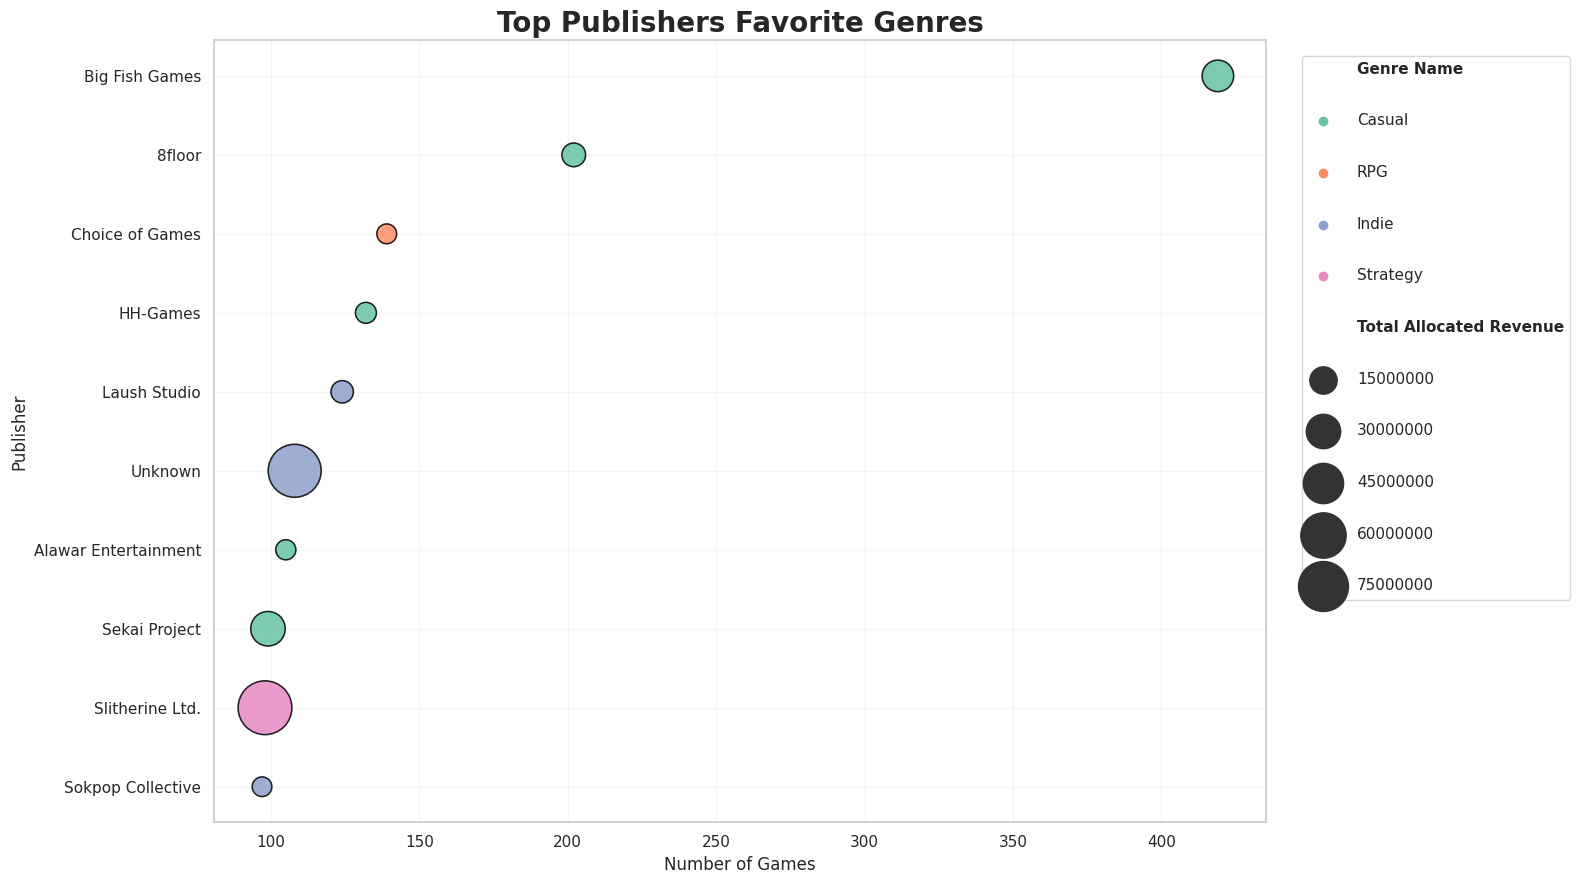

In [0]:
query = """
WITH ranked_publishers AS (

    SELECT
        publisher_name,
        genre_name,
        total_games,
        total_allocated_revenue,

        ROW_NUMBER() OVER (
            PARTITION BY publisher_name
            ORDER BY total_games DESC
        ) AS rn

    FROM steam.gold.publisher_genre_affinity
),

top_publishers AS (

    SELECT *
    FROM ranked_publishers
    WHERE rn = 1
)

SELECT *
FROM top_publishers

ORDER BY total_games DESC

LIMIT 10
"""

df = spark.sql(query)

display(df)

pdf = df.toPandas()

plt.figure(figsize=(16,9))

sns.scatterplot(
    data=pdf,
    x='total_games',
    y='publisher_name',
    hue='genre_name',
    size='total_allocated_revenue',
    palette='Set2',
    sizes=(200, 1500),
    alpha=0.85,
    edgecolor='black'
)

handles, labels = plt.gca().get_legend_handles_labels()

labels[0] = 'Genre Name'
labels[5] = 'Total Allocated Revenue'

legend = plt.legend(
    handles,
    labels,
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    borderaxespad=1,
    labelspacing=2.4,
    handletextpad=1.2,
)

legend.get_texts()[0].set_weight('bold')
legend.get_texts()[5].set_weight('bold')

plt.title(
    'Top Publishers Favorite Genres',
    fontsize=20,
    weight='bold'
)

plt.xlabel('Number of Games')
plt.ylabel('Publisher')

plt.grid(alpha=0.2)

plt.tight_layout()

plt.show()

### Interpretation

* **Strategic Genre Specialization:** The chart shows that many publishers tend to specialize in a single dominant genre rather than distributing their development pipelines or catalogs evenly across multiple categories.
* **The Casual Volume Play:** **Big Fish Games** strongly dominates the **Casual** tag with over **400 games**, placing it far ahead of all other publishers in the ranking. This, along with heavy casual concentrations from publishers like **8floor**, **HH-Games**, and **Alawar Entertainment**, confirms that the casual market supports high-volume publishing strategies.
* **Value Over Volume:** In contrast, publishers like **Slitherine Ltd.** focus primarily on **Strategy** games while generating very high allocated revenues relative to their catalog size. This indicates a highly profitable, specialized positioning aimed at a dedicated audience.
* **The Revenue Mismatch:** Bubble sizes reveal that having the largest catalog does not automatically translate into the highest revenue concentration. Some smaller, focused publishers generate substantial financial returns with fewer, more targeted releases.

**Strategic Takeaway:** The data highlights two different publishing strategies on Steam. Some publishers focus on releasing a very large number of games, especially in accessible genres like **Casual**, to maximize their visibility on the platform. Others, like **Slitherine Ltd.**, rely on a more specialized approach by focusing on niche genres such as **Strategy**. Instead of publishing hundreds of titles, they generate strong revenues through premium pricing and a loyal player community.


## Most Lucrative Genres

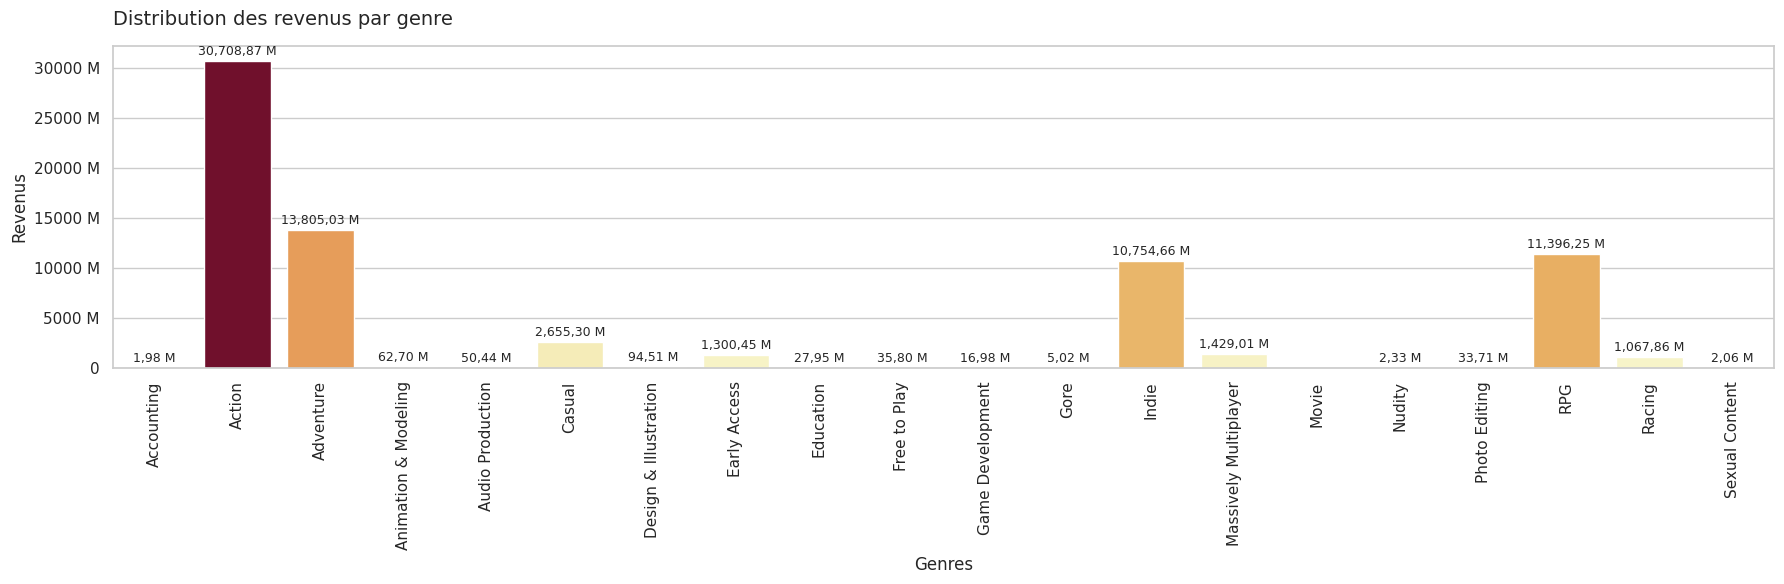

In [0]:
query = """
SELECT
    genre_name,
    SUM(total_allocated_revenue) AS total_revenue
FROM steam.gold.genre_platform_summary
GROUP BY genre_name
ORDER BY genre_name ASC  
LIMIT 20                 
"""

df = spark.sql(query)
pdf = df.toPandas()


plt.figure(figsize=(18, 6))


norm = plt.Normalize(pdf['total_revenue'].min(), pdf['total_revenue'].max())
palette = sns.color_palette("YlOrRd", as_cmap=True)
bar_colors = [palette(norm(value)) for value in pdf['total_revenue']]


ax = sns.barplot(
    data=pdf, 
    x='genre_name', 
    y='total_revenue', 
    palette=bar_colors
)


for p in ax.patches:
    height = p.get_height()
    if height > 0: 

        label_text = f"{height / 1000000:,.2f} M".replace('.', ',')
        ax.text(
            p.get_x() + p.get_width() / 2.,    
            height + (pdf['total_revenue'].max() * 0.01), 
            label_text, 
            ha='center',                       
            va='bottom', 
            fontsize=9
        )


plt.title('Distribution des revenus par genre', loc='left', fontsize=14, pad=15)
plt.xlabel('Genres', fontsize=12)
plt.ylabel('Revenus', fontsize=12)


plt.xticks(rotation=90, ha='center')

ax.yaxis.set_major_formatter(lambda x, pos: f'{int(x/1000000)} M' if x > 0 else '0')

plt.tight_layout()
plt.show()

### Interpretation

* **Undisputed Revenue Dominance:** **Action** games generate by far the highest total revenue on Steam, massively outperforming every other genre in the dataset. This positions action-oriented titles as the primary economic engine of the storefront.
* **The Core Revenue Pillars:** **Adventure**, **RPG**, and **Indie** follow as the platform's major commercial pillars. This demonstrates that both massive, mainstream AAA productions and smaller independent releases hold immense earning power on Steam.
* **The Volume vs. Value Disconnect:** Although **Indie** is the most populated genre by total number of titles, it generates less absolute revenue than **Action**. This highlights that extreme market saturation and catalog size do not automatically translate into higher market-wide earnings.
* **Resilient Secondary Markets:** Genres such as **Casual**, **Early Access**, and **Massively Multiplayer** still generate substantial revenues, proving that strong commercial ecosystems exist outside of the traditional single-player or action blockbusters.
* **Marginal Non-Gaming Software:** More specialized, non-gaming categories like **Education**, **Photo Editing**, and **Animation & Modeling** contribute only marginally to the platform’s total financial ecosystem.

**Strategic Takeaway** : The data confirms that Steam revenues are heavily concentrated within a few dominant, core gaming categories—led overwhelmingly by **Action**. While entering the Action, Adventure, or RPG spaces exposes a game to fierce volume competition, these genres offer the largest financial upside on the platform. Conversely, while niche software categories face practically zero competition, they operate within a drastically smaller economic space with a much lower revenue ceiling.

# Platform analysis

## Platform Availability

windows_games,mac_games,linux_games
55572,12742,8448


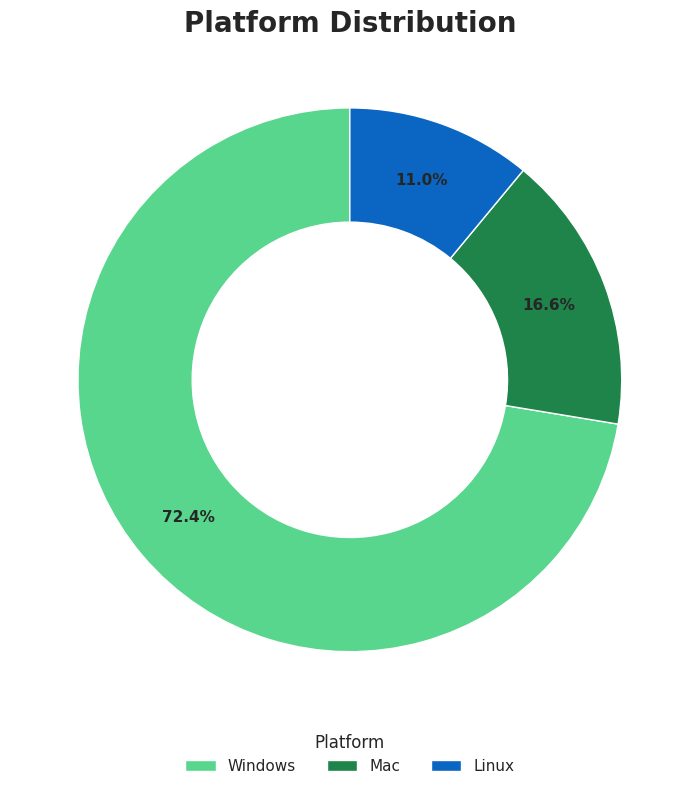

In [0]:
query = """
SELECT
    SUM(CASE WHEN windows = true THEN 1 ELSE 0 END) AS windows_games,
    SUM(CASE WHEN mac = true THEN 1 ELSE 0 END) AS mac_games,
    SUM(CASE WHEN linux = true THEN 1 ELSE 0 END) AS linux_games
FROM steam.gold.fact_games
"""

df = spark.sql(query)

display(df)

pdf = df.toPandas().melt(
    var_name='platform',
    value_name='games'
)

pdf['platform'] = pdf['platform'].str.replace('_games', '')
pdf['platform'] = pdf['platform'].str.capitalize()

colors = [
    '#58D68D',
    '#1E8449',
    '#0A66C2'
]

plt.figure(figsize=(8,8))

plt.pie(
    pdf['games'],
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={
        'width':0.42,
        'edgecolor':'white'
    },
    pctdistance=0.78,
    textprops={
        'fontsize':11,
        'weight':'bold'
    }
)

plt.legend(
    pdf['platform'],
    title='Platform',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
    frameon=False
)

plt.title(
    'Platform Distribution',
    fontsize=20,
    weight='bold'
)

plt.tight_layout()

plt.show()



### Interpretation

* **Windows** largely dominates Steam’s ecosystem, with more than **55,000 compatible games**, representing over **70% of the catalog**.
* **macOS** support is much smaller but still significant, with around **12,700 compatible games** available on the platform.
* **Linux** has the lowest share, with roughly **8,400 games**, reflecting its more niche position in PC gaming.
* The large gap between Windows and the other systems shows that most developers primarily focus on Windows compatibility to reach the widest audience.
* Even with smaller market shares, Mac and Linux still maintain meaningful game catalogs, making cross-platform support valuable for some developers.

**Strategic Takeaway** : For developers, **Windows remains the essential platform target** for maximizing visibility and player reach.  
However, tools like **Valve Proton** now allow many Windows games to run on Linux systems without requiring a full native port.  
As a result, developers can increasingly reach Linux and **Steam Deck** players simply by ensuring strong Windows compatibility and optimization.

_NB : Valve Proton is a tool created by Valve that lets many Windows games run on Linux systems, including the Steam Deck, without developers needing to create a separate Linux version._



## Genres by Platform

genre_name,windows_games,mac_games,linux_games
Indie,39653,9924,6972
Action,23723,4555,3376
Casual,22062,5126,3305
Adventure,21398,5026,3297
Strategy,10875,3000,1823
Simulation,10815,2436,1531
RPG,9525,2246,1524
Early Access,6140,898,632
Free to Play,3388,844,473
Sports,2660,506,287


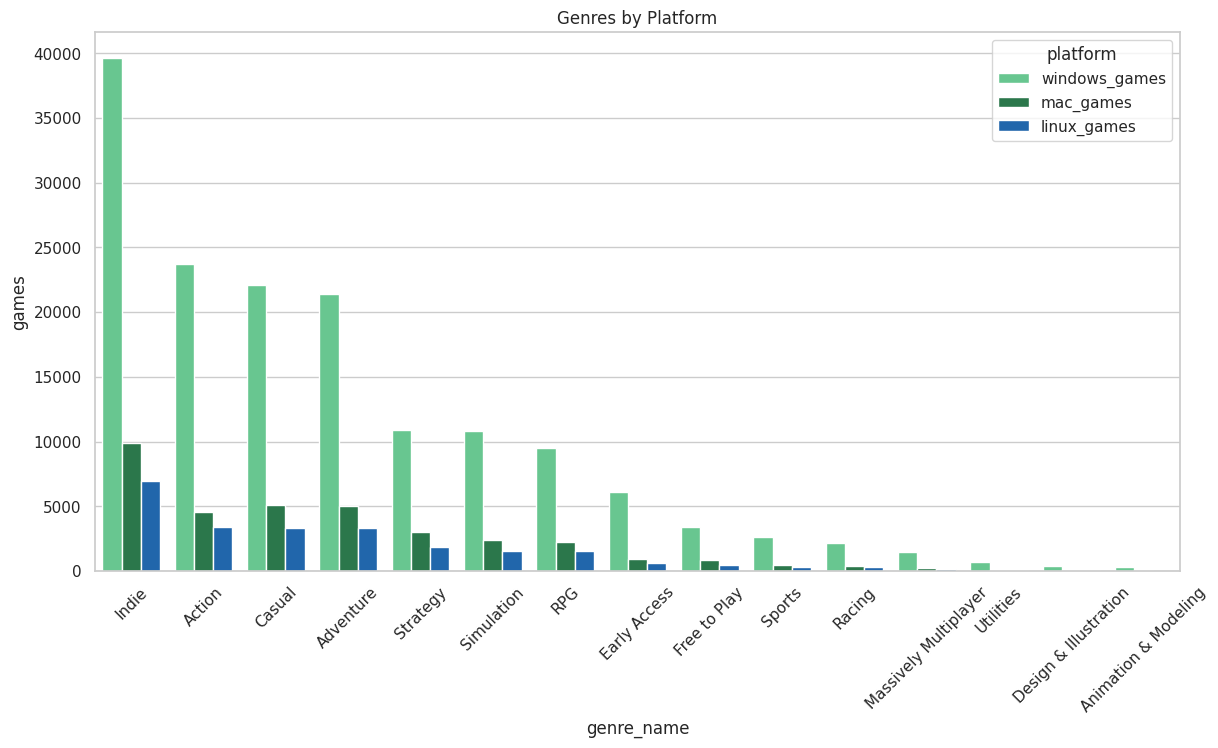

In [0]:

query = """
SELECT
    genre_name,
    windows_games,
    mac_games,
    linux_games
FROM steam.gold.genre_platform_summary
ORDER BY total_games DESC
LIMIT 15
"""

df = spark.sql(query)
display(df)

pdf = df.toPandas()

pdf_melted = pdf.melt(
    id_vars='genre_name',
    value_vars=['windows_games', 'mac_games', 'linux_games'],
    var_name='platform',
    value_name='games'
)

plt.figure(figsize=(14,7))
custom_colors = ['#58D68D', '#1E8449', '#0A66C2']

bar_colors = [custom_colors[i % len(custom_colors)] for i in range(len(pdf))]
sns.barplot(data=pdf_melted, x='genre_name', y='games', hue='platform', palette=bar_colors)
plt.xticks(rotation=45)
plt.title('Genres by Platform')
plt.show()


### Interpretation

* **Indie Dominance:** **Indie** games clearly dominate every operating system category, making them the most widely distributed genre across Windows, Mac, and Linux.
* **Mainstream Genre Presence:** **Action**, **Casual**, and **Adventure** also maintain a very strong cross-platform presence, showing that these popular genres are broadly accessible regardless of operating system.
* **Windows Leadership:** Across every genre, **Windows** consistently contains the largest number of games, confirming its role as the primary platform for PC game development.
* **Similar Platform Trends:** Although Mac and Linux catalogs are much smaller overall, the distribution of genres remains very similar to Windows. The same genres tend to dominate across all platforms.
* **Strong PC-Oriented Genres:** **Strategy**, **Simulation**, and **RPG** games maintain relatively solid support on Linux and Mac, reflecting the popularity of these genres among traditional PC gaming communities.
* **Smaller Specialized Categories:** Categories such as **Utilities**, **Animation & Modeling**, and **Design & Illustration** remain marginal across all operating systems.

**Strategic Takeaway** : The data suggests that Windows remains the main development target for nearly every genre. However, because genre distributions are very similar across all operating systems, developers releasing games in major genres like Indie, Action, or Adventure can still reach meaningful audiences on Mac and Linux through cross-platform support and compatibility tools like Proton.


# Conclusion : Market Determinants of Success on Steam

The global analysis of the Steam ecosystem highlights that video game success—measured through visibility, popularity, and sales potential—is not determined by a single variable. Instead, it relies on a strategic combination of market positioning, technical accessibility, and localized reach within an increasingly competitive storefront. 

The most commercially dominant and visible segments of the Steam market consistently revolve around games that successfully balance four core factors:

* **Strategic Genre Positioning:** While the marketplace is highly saturated—heavily defined by an immense volume of **Indie** titles—player engagement and market visibility remain strongly concentrated around foundational categories such as **Action, Adventure, Casual, Strategy, and Multiplayer** experiences. However, high representation within these genres does not automatically translate into stronger player appreciation. As shown throughout the analysis, success depends less on genre selection itself and more on execution quality, positioning, and immediate product discoverability within extremely crowded market segments.

* **Broad Technical Accessibility:** Maximizing global sales potential is directly tied to broad platform compatibility. **Windows** remains the mandatory primary distribution target, accounting for the overwhelming majority of the Steam catalog. However, the modern ecosystem increasingly rewards games capable of extending their reach to secondary platforms, particularly through compatibility with **Linux and handheld ecosystems such as the Steam Deck** via technologies like **Valve Proton**.

* **International Localization Reach:** Steam operates as a global marketplace where English functions as the foundational baseline for visibility and accessibility. To expand international audience reach and commercial exposure, English-first localization strategies should be strategically supplemented with major secondary regional languages such as French, German, Russian, or Simplified Chinese.

* **Balanced Market Pricing:** The analysis suggests that stronger commercial traction is more consistently associated with **accessible mid-range pricing strategies**, rather than extreme premium pricing or ultra-low-cost positioning. This reflects the importance of balancing perceived value, accessibility, and discoverability within a highly competitive storefront environment.

**In summary**, the Steam ecosystem does not reward production scale or publisher presence alone. Long-term commercial viability belongs to games capable of combining strong genre demand, broad technical and linguistic accessibility, and clear differentiation within an ultra-saturated marketplace.
